In [3]:
import os
from matplotlib import figure
from sklearn import linear_model

print("Jupyter is looking here:", os.getcwd())

Jupyter is looking here: /home/owais/PycharmProjects/AUTOWORTH_BACKEND


Visualizing Data Befor Starting Using Seabron

<Axes: xlabel='selling_price', ylabel='Count'>

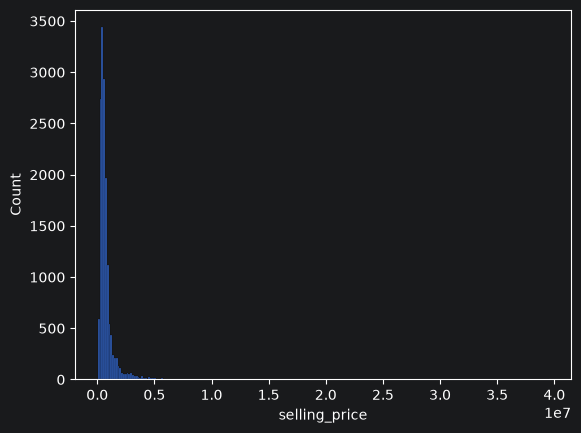

In [4]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("car.csv")
sns.histplot(df["selling_price"])

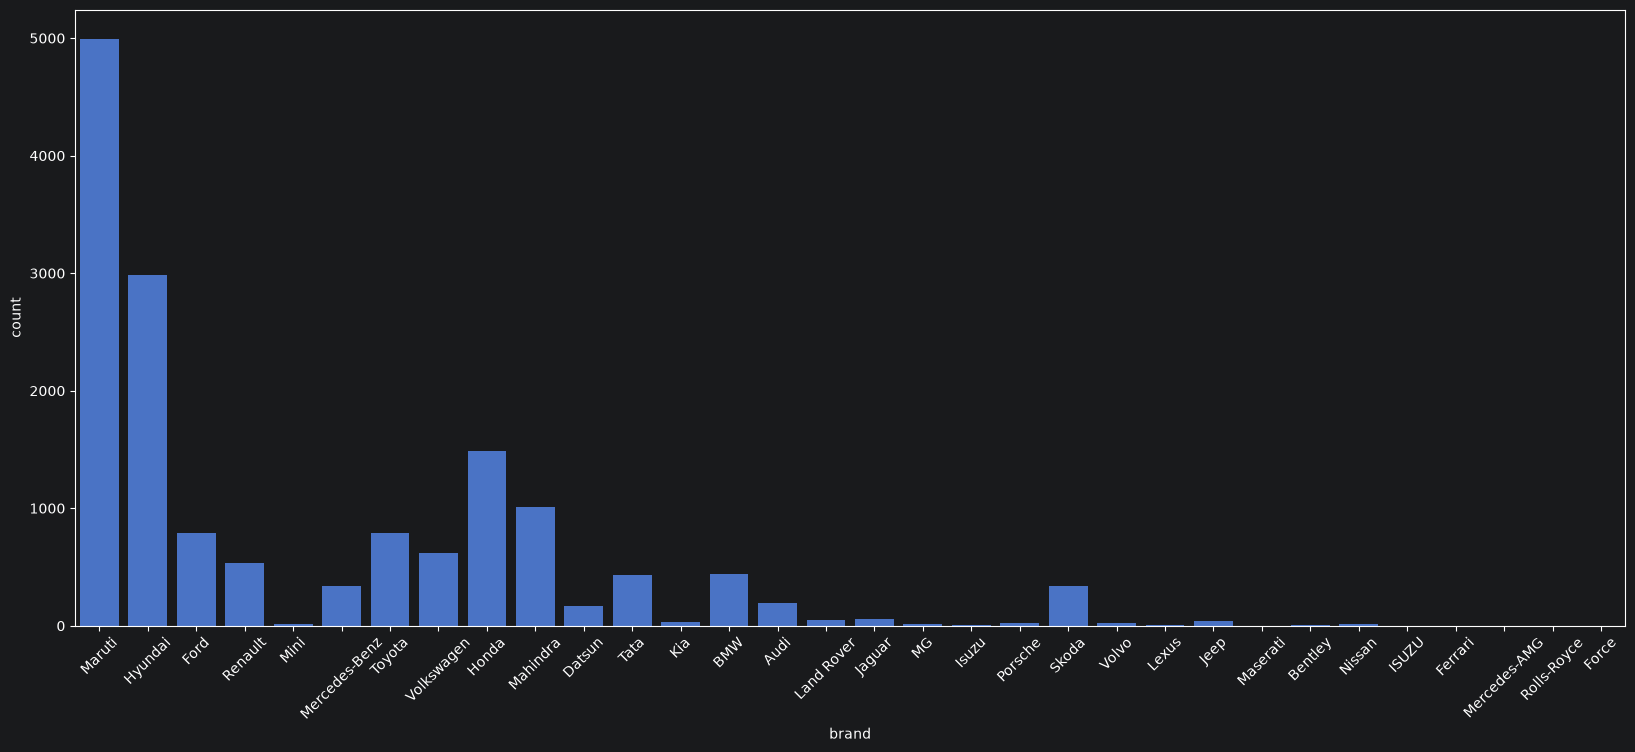

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,8))
sns.countplot(data=df, x="brand")
plt.xticks(rotation=45)
plt.show()

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
15406     250000
15407     925000
15408     425000
15409    1225000
15410    1200000
Name: selling_price, Length: 15411, dtype: int64


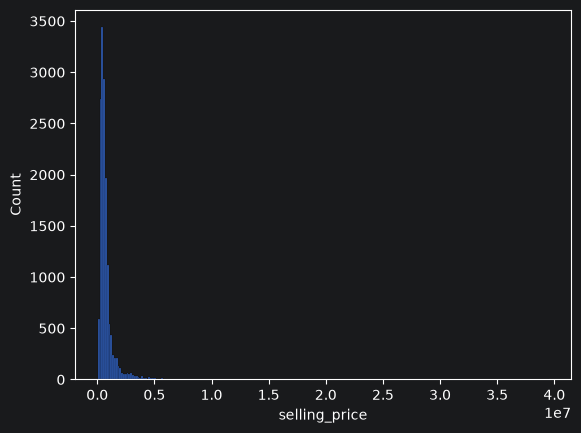

In [6]:
df["selling_price_lakh"] = df["selling_price"] / 100000
sns.histplot(df["selling_price"])
print(df["selling_price"])

Checking for skewness so we can decide which Function Transformer to apply

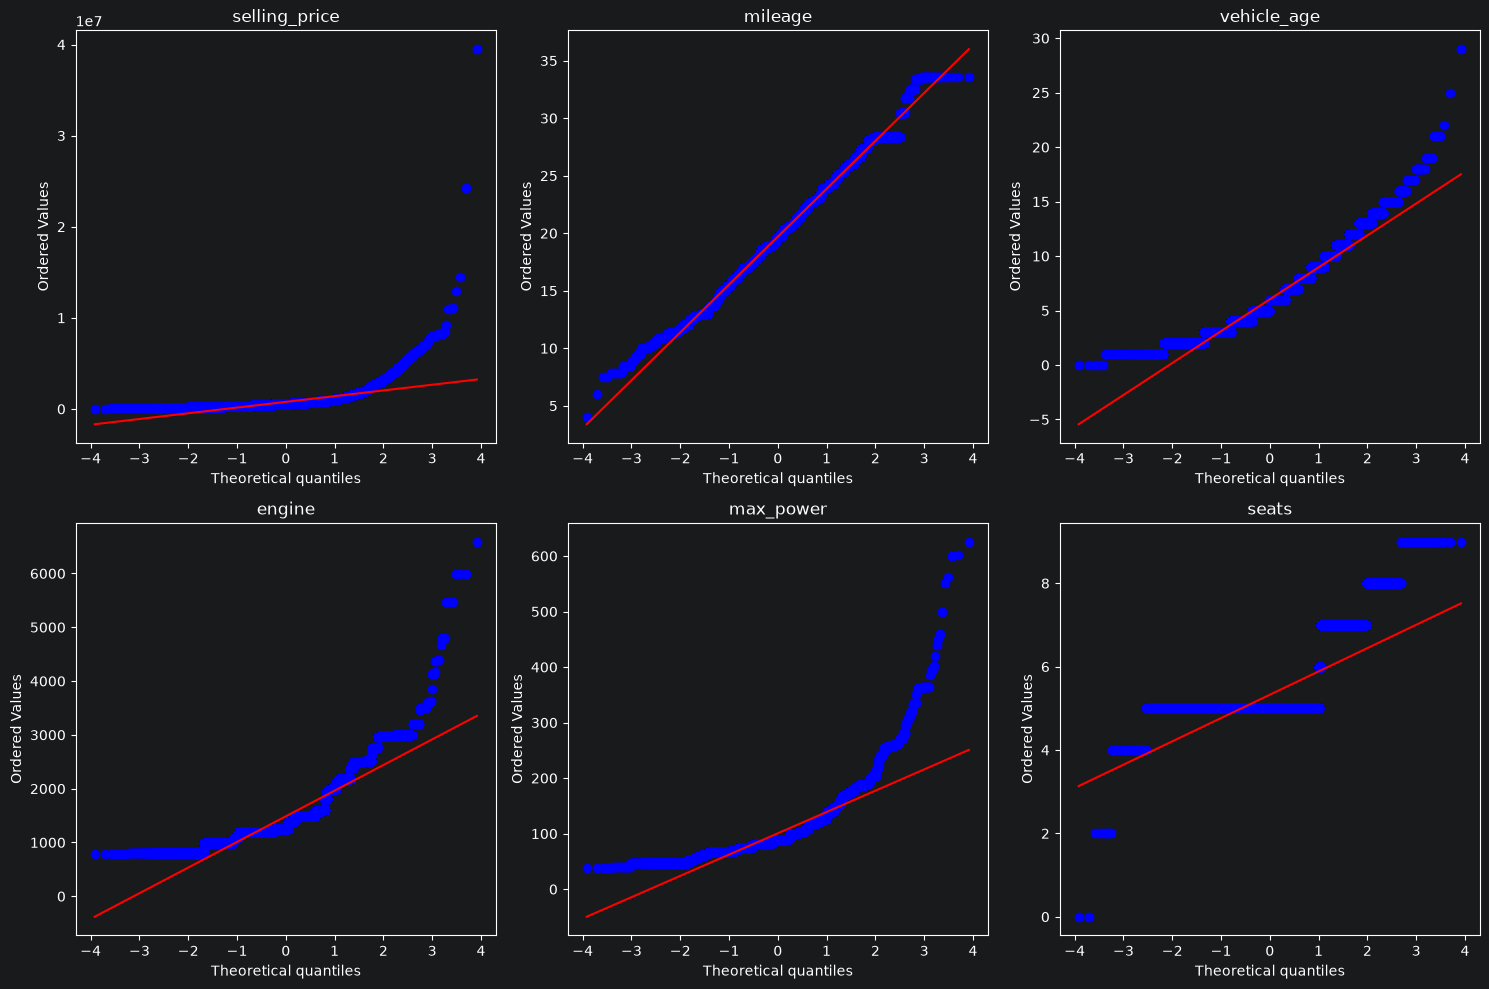

In [7]:
from scipy import stats
import matplotlib.pyplot as plt

columns = [
    "selling_price",
    "mileage",
    "vehicle_age",
    "engine",
    "max_power",
    "seats"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(col)

plt.tight_layout()
plt.show()

In [8]:
print(df[[
    "selling_price",
    "mileage",
    "vehicle_age",
    "engine",
    "max_power",
    "seats"
]].skew())

selling_price    10.047048
mileage           0.104961
vehicle_age       0.833712
engine            1.666467
max_power         2.485129
seats             2.039983
dtype: float64


AFTER ANAYZING DATA NW DOING DATA CLEANING PROCESS

In [9]:
df.shape

(15411, 15)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          15411 non-null  int64  
 1   car_name            15411 non-null  str    
 2   brand               15411 non-null  str    
 3   model               15411 non-null  str    
 4   vehicle_age         15411 non-null  int64  
 5   km_driven           15411 non-null  int64  
 6   seller_type         15411 non-null  str    
 7   fuel_type           15411 non-null  str    
 8   transmission_type   15411 non-null  str    
 9   mileage             15411 non-null  float64
 10  engine              15411 non-null  int64  
 11  max_power           15411 non-null  float64
 12  seats               15411 non-null  int64  
 13  selling_price       15411 non-null  int64  
 14  selling_price_lakh  15411 non-null  float64
dtypes: float64(3), int64(6), str(6)
memory usage: 1.8 MB


In [11]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,selling_price_lakh
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,1.20
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,5.50
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,2.15
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,2.26
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,5.70


In [12]:
df.isnull().sum()

Unnamed: 0            0
car_name              0
brand                 0
model                 0
vehicle_age           0
km_driven             0
seller_type           0
fuel_type             0
transmission_type     0
mileage               0
engine                0
max_power             0
seats                 0
selling_price         0
selling_price_lakh    0
dtype: int64

Identify Unique Values in Each Colummn

In [13]:
for col in ['brand', 'fuel_type', 'transmission_type', 'seller_type']:
    print(col, df[col].unique())

brand <StringArray>
[       'Maruti',       'Hyundai',          'Ford',       'Renault',
          'Mini', 'Mercedes-Benz',        'Toyota',    'Volkswagen',
         'Honda',      'Mahindra',        'Datsun',          'Tata',
           'Kia',           'BMW',          'Audi',    'Land Rover',
        'Jaguar',            'MG',         'Isuzu',       'Porsche',
         'Skoda',         'Volvo',         'Lexus',          'Jeep',
      'Maserati',       'Bentley',        'Nissan',         'ISUZU',
       'Ferrari',  'Mercedes-AMG',   'Rolls-Royce',         'Force']
Length: 32, dtype: str
fuel_type <StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str
transmission_type <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
seller_type <StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str


Chekcing For Duplicates

In [14]:
for col in df.columns:
    duplicates = df[col].duplicated().sum()
    print(f"{col}: {duplicates}")

Unnamed: 0: 0
car_name: 15290
brand: 15379
model: 15291
vehicle_age: 15387
km_driven: 11723
seller_type: 15408
fuel_type: 15406
transmission_type: 15409
mileage: 15000
engine: 15301
max_power: 15069
seats: 15403
selling_price: 14325
selling_price_lakh: 14325


In [15]:
df['model'].nunique()

df['vehicle_age'].nunique()

24

In [16]:
df.groupby(['brand', 'model']).ngroups

121

In [17]:
df.groupby(['brand', 'model', 'vehicle_age']).ngroups

811

In [18]:
df.groupby(['brand', 'model', 'vehicle_age', 'km_driven']).ngroups

11871

In [19]:
df.groupby(['brand', 'model', 'vehicle_age', 'km_driven', 'selling_price']).ngroups

15085

In [20]:
df.duplicated().sum()

np.int64(0)

                                    TRAINING MODELS AFTER THOROUGH DATA ANALYSIS

FIRST MODEL USING LINEAR REGRESSION

In [21]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df=pd.read_csv("car.csv")
df=pd.get_dummies(df,drop_first=True)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
x=df.drop("selling_price",axis=1)
y=df[["selling_price"]]
model=LinearRegression()
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
prediction=model.predict(X_test)
r2score=r2_score(y_test,prediction)
print(r2score)
df.head()

0.7406080169863216


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,car_name_Audi A6,car_name_Audi A8,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,0,9,120000,19.70,796,46.30,5,120000,False,False,...,False,False,False,True,False,False,False,False,True,True
1,1,5,20000,18.90,1197,82.00,5,550000,False,False,...,False,False,False,True,False,False,False,False,True,True
2,2,11,60000,17.00,1197,80.00,5,215000,False,False,...,False,True,False,True,False,False,False,False,True,True
3,3,9,37000,20.92,998,67.10,5,226000,False,False,...,False,False,False,True,False,False,False,False,True,True
4,4,6,30000,22.77,1498,98.59,5,570000,False,False,...,False,False,False,False,False,True,False,False,False,True


ABOVE MODEL GIVES RSQUARE SCORE OF 0.74 NW APPLYNG STANDARD SCALING AND TEHN RECALCULAITN R SQUARE

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df = pd.read_csv("car.csv")
df = pd.get_dummies(df, drop_first=True)
# --- Separate features and target ---
x = df.drop("selling_price", axis=1)
y = df[["selling_price"]]
# --- Split first, THEN scale ---
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
# --- Scale input features only ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# --- Train ---
model = LinearRegression()
model.fit(X_train, y_train)
# --- Evaluate ---
prediction = model.predict(X_test)
print("R² score:", round(r2_score(y_test, prediction), 4))

R² score: 0.7896


AFTER APPLYING ONEHOT ENCODING AND STANDARD SCALING SCORE IS 0.7896

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv("car.csv")
df = pd.get_dummies(df, drop_first=True)


x = df.drop("selling_price", axis=1)
y = df[["selling_price"]]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

# --- Scale ONLY those columns, leave onehot columns untouched ---
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


model = LinearRegression()
model.fit(X_train, y_train)


prediction = model.predict(X_test)
print("R² score:", round(r2_score(y_test, prediction), 4))

R² score: 0.7995


CONCLUSION:-StandardScaler's conclusion: scale only genuine numeric columns, not onehot columns — smallbut real R² improvement, confirmed by your test (0.789→0.795)

AS IN BEGINGIN WE HAD ANALYZED THE SKEWNESS OF DATA USING PROBPLOT/QQPLOT WE NEED TO APPLY FUNCTION TRANSFORMATIOSNS LIEK SQUARE TRANSFORM OR LOG TRANSFORM DEPENDING UPON THE DATA

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
df = pd.read_csv("car.csv")

df = pd.get_dummies(df, drop_first=True)
X = df.drop("selling_price", axis=1)
y = df["selling_price"]
# log transform target
y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(
X, y_log, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train, y_train_log)
# predict log price
pred_log = model.predict(X_test)
# convert back to actual price
pred_price = np.expm1(pred_log)
y_test_price = np.expm1(y_test_log)
print("R2 Score:", round(r2_score(y_test_price, pred_price), 4))
print("MAE:", round(mean_absolute_error(y_test_price, pred_price), 2))

R2 Score: 0.8907
MAE: 117887.35


I identified skewed columns using QQ plots, but I validated each transformation empirically by comparing R² before and after, rather than assuming distribution-shape fixes always help. Some transforms improved performance, others didn't, so I kept only the ones that measurably helped."

AFTER GETTING MAX R SQUARE OF 0.8907 now trying anotehr dataset wiht mro features

In [25]:
df2=pd.read_csv("delhicar.csv")
df2.head()

,city,make,model,variant,mileage,make_year,price,fuel_type,no_of_owners,color,body_type,transmission,registration_year,latest_publish_date
0,delhi-ncr,Hyundai,New i20,Sportz 1.2 MT Dual Tone,80637,2021,556000.0,petrol,1,silver,hatchback,manual,2021,2025-08-18 12:35:31
1,delhi-ncr,Maruti Suzuki,Vitara Brezza,VXi,41189,2021,630000.0,petrol,2,red,suv,manual,2021,2025-08-18 12:40:34
2,delhi-ncr,Honda,Amaze,1.2 S MT Petrol,17293,2018,506000.0,petrol,1,red,sedan,manual,2018,2025-08-18 12:50:12
3,delhi-ncr,Datsun,Redi-GO,T,43941,2016,182000.0,petrol,2,grey,hatchback,manual,2018,2025-08-18 10:45:45
4,delhi-ncr,Hyundai,Creta,1.6 SX Plus Auto Petrol,66029,2017,788000.0,petrol,1,white,suv,automatic,2017,2025-08-18 12:57:20


CHECK MISSING VALUES

In [26]:
df2.isnull().sum()

city                   0
make                   0
model                  0
variant                0
mileage                0
make_year              0
price                  0
fuel_type              0
no_of_owners           0
color                  1
body_type              0
transmission           0
registration_year      0
latest_publish_date    0
dtype: int64

In [27]:
df.duplicated().sum()
df[df.duplicated()]

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,car_name_Audi A6,car_name_Audi A8,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual


In [28]:
for col in df.columns:
    print(col, df[col].duplicated().sum())

Unnamed: 0 0
vehicle_age 15387
km_driven 11723
mileage 15000
engine 15301
max_power 15069
seats 15403
selling_price 14325
car_name_Audi A6 15409
car_name_Audi A8 15409
car_name_Audi Q7 15409
car_name_BMW 3 15409
car_name_BMW 5 15409
car_name_BMW 6 15409
car_name_BMW 7 15409
car_name_BMW X1 15409
car_name_BMW X3 15409
car_name_BMW X4 15409
car_name_BMW X5 15409
car_name_BMW Z4 15409
car_name_Bentley Continental 15409
car_name_Datsun GO 15409
car_name_Datsun RediGO 15409
car_name_Datsun redi-GO 15409
car_name_Ferrari GTC4Lusso 15409
car_name_Force Gurkha 15409
car_name_Ford Aspire 15409
car_name_Ford Ecosport 15409
car_name_Ford Endeavour 15409
car_name_Ford Figo 15409
car_name_Ford Freestyle 15409
car_name_Honda Amaze 15409
car_name_Honda CR 15409
car_name_Honda CR-V 15409
car_name_Honda City 15409
car_name_Honda Civic 15409
car_name_Honda Jazz 15409
car_name_Honda WR-V 15409
car_name_Hyundai Aura 15409
car_name_Hyundai Creta 15409
car_name_Hyundai Elantra 15409
car_name_Hyundai Grand 1

In [29]:
df2=df2.dropna()

In [30]:
df2.isnull().sum()

city                   0
make                   0
model                  0
variant                0
mileage                0
make_year              0
price                  0
fuel_type              0
no_of_owners           0
color                  0
body_type              0
transmission           0
registration_year      0
latest_publish_date    0
dtype: int64

In [31]:
df2.columns

Index(['city', 'make', 'model', 'variant', 'mileage', 'make_year', 'price',
       'fuel_type', 'no_of_owners', 'color', 'body_type', 'transmission',
       'registration_year', 'latest_publish_date'],
      dtype='str')

In [32]:
df2["registration_year"]

0       2021
1       2021
2       2018
3       2018
4       2017
        ... 
8132    2018
8133    2021
8134    2022
8135    2016
8136    2021
Name: registration_year, Length: 8136, dtype: int64

CHECKING SKEWNESS IN DATA USING PROBPLOT/QQPLOT

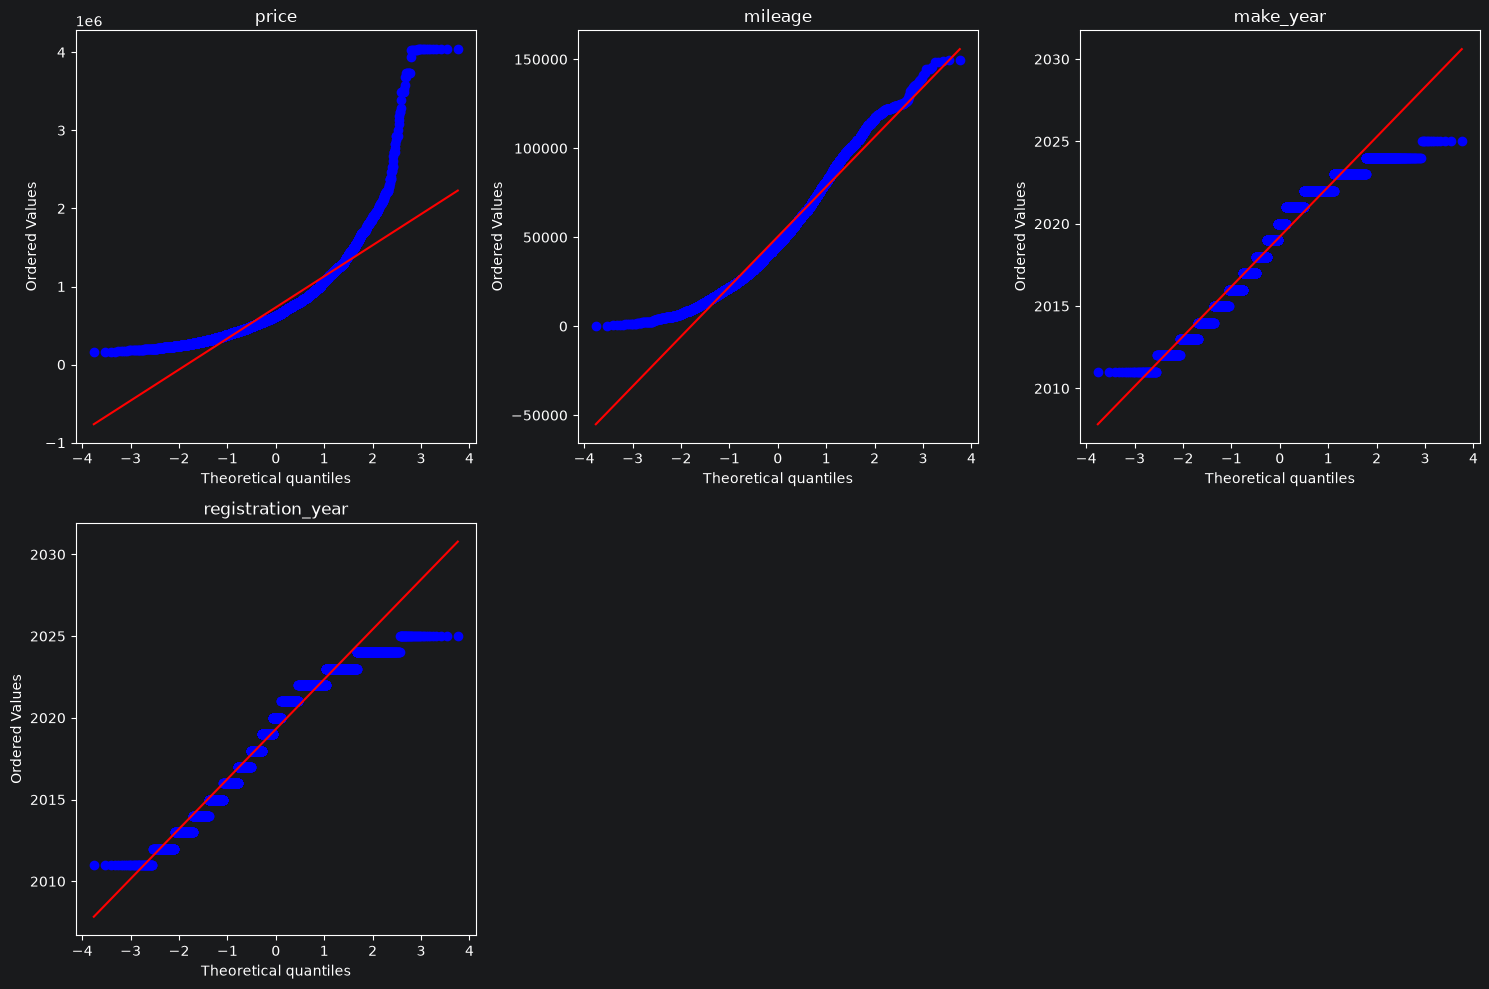

In [33]:
from scipy import stats
import matplotlib.pyplot as plt

columns = [
    "price",
    "mileage",
    "make_year",
    "registration_year",


]

plt.figure(figsize=(15,10))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns
    stats.probplot(df2[col], dist="norm", plot=plt)
    plt.title(col)

plt.tight_layout()
plt.show()

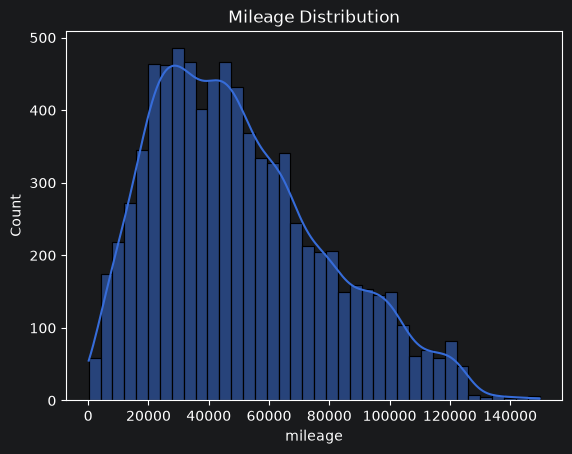

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df2['mileage'], kde=True)
plt.title('Mileage Distribution')
plt.show()

NOW TRAING  A MODEL ON DELHI CAR DATASET WITHOUT NAY TARSNFORMATIONS

In [35]:
print(df2["price"].dtype)

float64


Checking datatypes of all columns

In [36]:
print(df2.dtypes)

city                       str
make                       str
model                      str
variant                    str
mileage                  int64
make_year                int64
price                  float64
fuel_type                  str
no_of_owners             int64
color                      str
body_type                  str
transmission               str
registration_year        int64
latest_publish_date        str
dtype: object


In [37]:
df.head()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,car_name_Audi A6,car_name_Audi A8,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,0,9,120000,19.70,796,46.30,5,120000,False,False,...,False,False,False,True,False,False,False,False,True,True
1,1,5,20000,18.90,1197,82.00,5,550000,False,False,...,False,False,False,True,False,False,False,False,True,True
2,2,11,60000,17.00,1197,80.00,5,215000,False,False,...,False,True,False,True,False,False,False,False,True,True
3,3,9,37000,20.92,998,67.10,5,226000,False,False,...,False,False,False,True,False,False,False,False,True,True
4,4,6,30000,22.77,1498,98.59,5,570000,False,False,...,False,False,False,False,False,True,False,False,False,True


In [51]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df2=pd.read_csv("delhicar.csv")
df2=df2.drop("latest_publish_date",axis=1)
df2=pd.get_dummies(df2,drop_first=True)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
x=df2.drop("price",axis=1)
y=df2[["price"]]
model=LinearRegression()
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
prediction=model.predict(X_test)
r2score=r2_score(y_test,prediction)


train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

print(r2score)
df.head()

Train R²: 0.9535307574015496
Test R²: 0.9493015254768048
0.9493015254768048


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,car_name_Audi A6,car_name_Audi A8,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,0,9,120000,19.70,796,46.30,5,120000,False,False,...,False,False,False,True,False,False,False,False,True,True
1,1,5,20000,18.90,1197,82.00,5,550000,False,False,...,False,False,False,True,False,False,False,False,True,True
2,2,11,60000,17.00,1197,80.00,5,215000,False,False,...,False,True,False,True,False,False,False,False,True,True
3,3,9,37000,20.92,998,67.10,5,226000,False,False,...,False,False,False,True,False,False,False,False,True,True
4,4,6,30000,22.77,1498,98.59,5,570000,False,False,...,False,False,False,False,False,True,False,False,False,True


  After traing liena rgeression model we can see that we ar egetting score of 0.95 but there might be chnace that model may overift so we need to check if onehot encoding got applied in wrong column whcih contains many unqiye values and total rows/unqiue value is <10 because this wil cerate mutltioe columsn and mdel will overift or byehart those cilumns

FIRST TRYING TO SEE WHAT WILL HAPPEN IF WE REMVOE VARINATS COLUMN BECAUSE IT HAS MANY UQYE VALUES

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df2=pd.read_csv("delhicar.csv")
df2=df2.drop("latest_publish_date",axis=1)
df2=df2.drop("variant",axis=1)
df2=pd.get_dummies(df2,drop_first=True)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
x=df2.drop("price",axis=1)
y=df2[["price"]]
model=LinearRegression()
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
prediction=model.predict(X_test)
r2score=r2_score(y_test,prediction)


train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

print(r2score)


Train R²: 0.9018184598189581
Test R²: 0.8657624317308963
0.8657624317308963


After removing varinats column now we can see that w got r square of 0.86 whihc cncludes that variant is an imprtat feature but we should solve curse of dimensionality for that particualr column we could nwo do that b grouping rare brands udner rare_brandscolumn so that numebr fo uqiye varants egt redced because if we dont increase  total rows/nuniqye to >10 it will cerate multilecoumns and mdoel will ovrfit

In [ ]:
df2=df2.drop("latest_publish_date",axis=1)

In [39]:
pd.read_csv("delhicar.csv").nunique().sort_values(ascending=False).head(20)

latest_publish_date    5658
mileage                5604
price                  1963
variant                1343
model                   158
make                     21
color                    16
city                     16
make_year                15
registration_year        15
body_type                 6
fuel_type                 6
no_of_owners              3
transmission              2
dtype: int64

In [40]:
raw_df = pd.read_csv("delhicar.csv")
print(raw_df.dtypes)

city                       str
make                       str
model                      str
variant                    str
mileage                  int64
make_year                int64
price                  float64
fuel_type                  str
no_of_owners             int64
color                      str
body_type                  str
transmission               str
registration_year        int64
latest_publish_date        str
dtype: object


In [43]:
df2.columns

Index(['mileage', 'make_year', 'price', 'no_of_owners', 'registration_year',
       'city_bangalore', 'city_chandigarh', 'city_chennai', 'city_delhi',
       'city_delhi-ncr',
       ...
       'color_silver', 'color_violet', 'color_white', 'color_yellow',
       'body_type_hatchback', 'body_type_muv', 'body_type_sedan',
       'body_type_suv', 'body_type_wagon', 'transmission_manual'],
      dtype='str', length=1565)

In [5]:
df2=pd.read_csv("delhicar.csv")
df2["variant"].value_counts()
df2.nunique()

city                     16
make                     21
model                   158
variant                1343
mileage                5604
make_year                15
price                  1963
fuel_type                 6
no_of_owners              3
color                    16
body_type                 6
transmission              2
registration_year        15
latest_publish_date    5658
dtype: int64

In [6]:
counts = df2["variant"].value_counts()
print(counts[counts<15])
print("Variants with <5 rows:", (counts < 5).sum())
print("Variants with <10 rows:", (counts < 10).sum())
print("Variants with <15 rows:", (counts < 15).sum())
print("Variants with <20 rows:", (counts < 20).sum())

variant
Alpha 1.5 AT                                14
Delta 1.4 MT                                14
XT Petrol                                   14
HTX G                                       14
1.6 SX AT VTVT                              14
                                            ..
Comfortline Plus 1.0L MPI                    1
Trendline 1.0 Petrol+cng(outside fitted)     1
4x2 AT                                       1
1.5 S MT Diesel                              1
SX (O) Connect 1.2 MT                        1
Name: count, Length: 1217, dtype: int64
Variants with <5 rows: 907
Variants with <10 rows: 1126
Variants with <15 rows: 1217
Variants with <20 rows: 1267


In [9]:
print((counts<5).sum())

907


Now to remove curse of diemtinality we shoud group rare bransd wosose cout is less than 15 inoto rare categoru and then apply oenhot encoding

In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df2=pd.read_csv("delhicar.csv")

# remove curse of dimensionality form variants by grouping rare varinats udner other
valuecounts=df2["variant"].value_counts()
rarelements=valuecounts[valuecounts<15].index
df2["variant"]=df2["variant"].replace(rarelements,"Other")
df2=df2.drop("latest_publish_date",axis=1)
df2=pd.get_dummies(df2,drop_first=True)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
x=df2.drop("price",axis=1)
y=df2[["price"]]
model=LinearRegression()
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
prediction=model.predict(X_test)
r2score=r2_score(y_test,prediction)


train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

print(r2score)


Train R²: 0.9080644739692731
Test R²: 0.870255142259133
0.870255142259133


Now applying ONehot Encoding on price from above code

In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import  r2_score,mean_absolute_error
import numpy as np

le = LabelEncoder()
df2 = pd.read_csv("delhicar.csv")

# remove curse of dimensionality from variants by grouping rare variants under "Other"
valuecounts = df2["variant"].value_counts()
rarelements = valuecounts[valuecounts < 15].index
df2["variant"] = df2["variant"].replace(rarelements, "Other")

print("Variant categories after grouping:", df2["variant"].nunique())   # ← INSERT HERE

df2 = df2.drop("latest_publish_date", axis=1)
df2 = pd.get_dummies(df2, drop_first=True)   # variant becomes variant_XXX columns from here onward

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df2["price"]=np.log1p(df2["price"])
x = df2.drop("price", axis=1)
y = df2["price"]

model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

Variant categories after grouping: 127
Train R²: 0.969384118369973
Test R²: 0.9606493575585063


AFTER APPLYING LOG TRANSFORM ON PRICE THE R SQAURE JUMPED FROM 0.89 TO 0.9604

Conclusion :-the max rsqure which we got from liner regression on cardekho dataset and delhicar datatset where 0.89 and 0.96 respectively we ar egetitng more score in dekhicar dataset because it ha sother imortnat features such as color ,owner and many othr factors that play an important role in a car's selling price.

Next steps :- we will contintue workign o car dekho dataset because it its data isnt limited to any state and no further optimizations on model trained on delhicar dataset because  it has rsquare sore of 0.96 already.

First we have to design a pipeline for Linear Regression Model each model will be having its own pipeline

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
linearmodeldf = pd.read_csv("car.csv")
print(linearmodeldf.columns.tolist())



X = linearmodeldf.drop("selling_price", axis=1)
y = linearmodeldf["selling_price"]
# log transform target
y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(
X, y_log, test_size=0.2, random_state=42
)
tf1=ColumnTransformer([
    ("Onehotencoder",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),["car_name","brand","model","fuel_type","seller_type"]),
    ("Logtransformer",FunctionTransformer(np.log1p),["km_driven"]),
    ("StandardScaler",StandardScaler(),["vehicle_age","engine","max_power","mileage"]),
])
pipeline=Pipeline(
    [
        ("preprocessor",tf1),
        (
         "model",LinearRegression()
        )
    ]
)


pipeline.fit(X_train, y_train_log)
# predict log price

# testing model with custom input

# custom_input = pd.DataFrame({
#     "car_name": ["Honda City"],
#     "brand": ["Honda"],
#     "model": ["City"],
#     "vehicle_age": [5],
#     "km_driven": [45000],
#     "seller_type": ["Dealer"],
#     "fuel_type": ["Petrol"],
#     "engine": [1498],
#     "mileage": [17.8],
#     "max_power": [117.3]
# })

custom_input = pd.DataFrame({
    "car_name": ["Mercedes-Benz C-Class"],
    "brand": ["Mercedes-Benz"],
    "model": ["C-Class"],
    "vehicle_age": [4],
    "km_driven": [38000],
    "seller_type": ["Dealer"],
    "fuel_type": ["Diesel"],
    "engine": [1950],
    "mileage": [19.0],
    "max_power": [191.0]
})

pred_log = pipeline.predict(custom_input)
pred_price = np.expm1(pred_log)

print(f"Predicted Price: ₹{pred_price[0]:,.0f}")

pred_log = pipeline.predict(X_test)
# convert back to actual price
pred_price = np.expm1(pred_log)
y_test_price = np.expm1(y_test_log)
print("R2 Score:", round(r2_score(y_test_price, pred_price), 4))
print("MAE:", round(mean_absolute_error(y_test_price, pred_price), 2))



['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Predicted Price: ₹2,438,945
R2 Score: 0.9061
MAE: 118263.41


In [17]:
import pandas as pd
testdf=pd.read_csv("car.csv")
testdf.nunique()

Unnamed: 0           15411
car_name               121
brand                   32
model                  120
vehicle_age             24
km_driven             3688
seller_type              3
fuel_type                5
transmission_type        2
mileage                411
engine                 110
max_power              342
seats                    8
selling_price         1086
dtype: int64

Achieved max r square of 0.907 in linear regression model on cardekho dataset and Created a compelte linear regression pipeline

In [3]:
print(linearmodeldf.shape[0] / linearmodeldf['car_name'].nunique())

127.36363636363636


Exporting LinearRegression Pipeline

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
linearmodeldf = pd.read_csv("car.csv")
print(linearmodeldf.columns.tolist())



X = linearmodeldf.drop("selling_price", axis=1)
y = linearmodeldf["selling_price"]
# log transform target
y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(
X, y_log, test_size=0.2, random_state=42
)
tf1=ColumnTransformer([
    ("Onehotencoder",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),["car_name","brand","model","fuel_type","seller_type"]),
    ("Logtransformer",FunctionTransformer(np.log1p),["km_driven"]),
    ("StandardScaler",StandardScaler(),["vehicle_age","engine","max_power","mileage"]),
])
pipeline=Pipeline(
    [
        ("preprocessor",tf1),
        (
         "model",LinearRegression()
        )
    ]
)


pipeline.fit(X_train, y_train_log)
# predict log price

# testing model with custom input

# custom_input = pd.DataFrame({
#     "car_name": ["Honda City"],
#     "brand": ["Honda"],
#     "model": ["City"],
#     "vehicle_age": [5],
#     "km_driven": [45000],
#     "seller_type": ["Dealer"],
#     "fuel_type": ["Petrol"],
#     "engine": [1498],
#     "mileage": [17.8],
#     "max_power": [117.3]
# })

custom_input = pd.DataFrame({
    "car_name": ["Mercedes-Benz C-Class"],
    "brand": ["Mercedes-Benz"],
    "model": ["C-Class"],
    "vehicle_age": [4],
    "km_driven": [38000],
    "seller_type": ["Dealer"],
    "fuel_type": ["Diesel"],
    "engine": [1950],
    "mileage": [19.0],
    "max_power": [191.0]
})
# calculating train r square
train_pred=pipeline.predict(X_train)


pred_log = pipeline.predict(custom_input)
pred_price = np.expm1(pred_log)

print(f"Predicted Price: ₹{pred_price[0]:,.0f}")

pred_log = pipeline.predict(X_test)
# convert back to actual price
pred_price = np.expm1(pred_log)
y_test_price = np.expm1(y_test_log)
print("R2  test Score:", round(r2_score(y_test_price, pred_price), 4))
print("r2 train score",r2_score(np.expm1(train_pred),np.expm1(y_train_log)))
print("MAE:", round(mean_absolute_error(y_test_price, pred_price), 2))

# joblib.dump(pipeline,"linearmodel.pkl")


['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Predicted Price: ₹2,438,945
R2  test Score: 0.9061
r2 train score 0.9157502772438825
MAE: 118263.41


Now traing Rando forest

In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
linearmodeldf = pd.read_csv("car.csv")
print(linearmodeldf.columns.tolist())



X = linearmodeldf.drop("selling_price", axis=1)
y = linearmodeldf["selling_price"]
# log transform target
y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(
X, y_log, test_size=0.2, random_state=42
)
tf1=ColumnTransformer([
    ("Onehotencoder",OneHotEncoder(sparse_output=False,handle_unknown="ignore"),["car_name","brand","model","fuel_type","seller_type"]),
    ("Logtransformer",FunctionTransformer(np.log1p),["km_driven"]),
    ("StandardScaler",StandardScaler(),["vehicle_age","engine","max_power","mileage"]),
])
pipeline=Pipeline(
    [
        ("preprocessor",tf1),
        (
         "model",RandomForestRegressor()
        )
    ]
)


pipeline.fit(X_train, y_train_log)
# predict log price

# testing model with custom input

# custom_input = pd.DataFrame({
#     "car_name": ["Honda City"],
#     "brand": ["Honda"],
#     "model": ["City"],
#     "vehicle_age": [5],
#     "km_driven": [45000],
#     "seller_type": ["Dealer"],
#     "fuel_type": ["Petrol"],
#     "engine": [1498],
#     "mileage": [17.8],
#     "max_power": [117.3]
# })

custom_input = pd.DataFrame({
    "car_name": ["Mercedes-Benz C-Class"],
    "brand": ["Mercedes-Benz"],
    "model": ["C-Class"],
    "vehicle_age": [4],
    "km_driven": [38000],
    "seller_type": ["Dealer"],
    "fuel_type": ["Diesel"],
    "engine": [1950],
    "mileage": [19.0],
    "max_power": [191.0]
})
# calculating train r square
train_pred=pipeline.predict(X_train)


pred_log = pipeline.predict(custom_input)
pred_price = np.expm1(pred_log)

print(f"Predicted Price: ₹{pred_price[0]:,.0f}")

pred_log = pipeline.predict(X_test)
# convert back to actual price
pred_price = np.expm1(pred_log)
y_test_price = np.expm1(y_test_log)
print("R2  test Score:", round(r2_score(y_test_price, pred_price), 4))
print("r2 train score",r2_score(np.expm1(train_pred),np.expm1(y_train_log)))
print("MAE:", round(mean_absolute_error(y_test_price, pred_price), 2))

joblib.dump(pipeline,"randommodel.pkl")


['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Predicted Price: ₹3,489,384
R2  test Score: 0.9356
r2 train score 0.9542444985438528
MAE: 100677.68


['randommodel.pkl']